In [1]:
from typing_extensions import TypedDict, Optional, Annotated
from operator import or_

from langgraph.graph.message import add_messages
from langchain_core.messages import AnyMessage

In [2]:
from langchain_mcp_adapters.client import MultiServerMCPClient
from langchain_mcp_adapters.tools import load_mcp_tools
from langchain_tavily import TavilySearch

    "stock_aggregator": ["health_check", "analyze_stock"],
    "allocation_agent": ["health_check", "get_allocation"],
    "portfolio_agent": ["health_check", "analyze_portfolio"],
    "portfolio_analysis_agent": ["health_check", "analyze_portfolio"],
    "diversification_agent": ["health_check", "analyze_portfolio"],
    "correlation_agent": ["health_check", "analyze_correlation"],
    "fundamental_documents_agent": [
        "health_check",
        "get_fundamental_report",
        "query_transcripts",
        "get_company_news",
        "swot_analysis",
    ],
    "memory_agent": ["health_check", "analyze_memory"],
    "explain_agent": ["health_check", "analyze_explain"],
    "qna_agent": ["health_check", "query_transcripts", "get_company_news"],
    "swot_agent": ["health_check", "swot_analysis"],
}

In [7]:
stock_mcp_client = MultiServerMCPClient({
    "stock-based_analyser" : {
        "command" : "python",
        "args" : ["apis/start_mcp_server.py", "stock_aggregator"],
        "transport" : "stdio",
    }
})

allocation_mcp_client = MultiServerMCPClient({
    "allocation-based_analyser" : {
        "command" : "python",
        "args" : ["apis/start_mcp_server.py", "allocation_agent"],
        "transport" : "stdio",
    }
})

portfolio_mcp_client = MultiServerMCPClient({
    "portfolio-based_analyser" : {
        "command" : "python",
        "args" : ["apis/start_mcp_server.py", "portfolio_agent"],
        "transport" : "stdio",
    }
})

correlation_mcp_client = MultiServerMCPClient({
    "correlation-based_analyser" : {
        "command" : "python",
        "args" : ["apis/start_mcp_server.py", "correlation_agent"],
        "transport" : "stdio",
    }
})

fundamental_mcp_client = MultiServerMCPClient({
    "fundamental-based_analyser" : {
        "command" : "python",
        "args" : ["apis/start_mcp_server.py", "fundamental_documents_agent"],
        "transport" : "stdio",
    }
})

memory_mcp_client = MultiServerMCPClient({
    "memory-based_analyser" : {
        "command" : "python",
        "args" : ["apis/start_mcp_server.py", "memory_agent"],
        "transport" : "stdio",
    }
})
    
explainability_mcp_client = MultiServerMCPClient({
    "explainability-based_analyser" : {
        "command" : "python",
        "args" : ["apis/start_mcp_server.py", "explain_agent"],
        "transport" : "stdio",
    }
})

qna_mcp_client = MultiServerMCPClient({
    "qna-based_analyser" : {
        "command" : "python",
        "args" : ["apis/start_mcp_server.py", "qna_agent"],
        "transport" : "stdio",
    }
})

swot_mcp_client = MultiServerMCPClient({
    "swot-based_analyser" : {
        "command" : "python",
        "args" : ["apis/start_mcp_server.py", "swot_agent"],
        "transport" : "stdio",
    }
})

In [10]:
from dotenv import load_dotenv
load_dotenv()

True

In [8]:
stock_mcp_tools = await stock_mcp_client.get_tools()
allocation_mcp_tools = await allocation_mcp_client.get_tools()
portfolio_mcp_tools = await portfolio_mcp_client.get_tools()
correlation_mcp_tools = await correlation_mcp_client.get_tools()
fundamental_mcp_tools = await fundamental_mcp_client.get_tools()
memory_mcp_tools = await memory_mcp_client.get_tools()
explainability_mcp_tools = await explainability_mcp_client.get_tools()
qna_mcp_tools = await qna_mcp_client.get_tools()
swot_mcp_tools = await swot_mcp_client.get_tools()

In [11]:

from langchain_tavily import TavilySearch

tool_tavily=TavilySearch(max_results=2)

In [29]:
class State(TypedDict, total=False):
    messages: Annotated[list[AnyMessage], add_messages]
    porfolio: Optional[dict]

In [18]:
from langgraph.prebuilt import create_react_agent

In [15]:
import httpx
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-3.5-turbo",
    temperature=0,
    http_client=httpx.Client(verify=False)
)

/Users/abhijit/Desktop/Stock_Project/Stock_value_pred_NSE/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [33]:
from langgraph.types import interrupt, Command
from langchain.tools import tool

@tool
def get_portfolio(state: State) -> State:
    """This function interrupts the agent's execution to get the user's portfolio details. 
    The user is prompted to provide their portfolio in a specific format, which includes the ticker, quantity, and total amount invested in each stock. The provided portfolio details are then stored in the state under the key "portfolio" for later use by the agent.
    """
    
    user_portfolio = interrupt("Please provide your portfolio details in the following format: \nTicker: Quantity\nFor example:\nAAPL: 10\nGOOGL: 5, and the total amount invested in each stock.")
    state["portfolio"] = user_portfolio
    return state


In [34]:
tools = [
    *stock_mcp_tools,
    *allocation_mcp_tools,
    *portfolio_mcp_tools,
    *correlation_mcp_tools,
    *fundamental_mcp_tools,
    *memory_mcp_tools,
    *explainability_mcp_tools,
    *qna_mcp_tools,
    *swot_mcp_tools,
    tool_tavily,
    get_portfolio
]

In [35]:
react_agent = create_react_agent(model=llm, tools=tools)

/var/folders/5c/4q6l3d092150jfps5bkhkpqc0000gn/T/ipykernel_97742/1723012251.py:1: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  react_agent = create_react_agent(model=llm, tools=tools)


In [36]:
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

In [37]:
async def tool_calling_llm(state: State):
    response = await llm_with_tools.ainvoke(state["messages"])  # ✅ FULL list
    state["messages"].append(response)
    return state

In [38]:
from langchain_core.messages import AIMessage

def check_finish(state: State):
    state["messages"].append(AIMessage(content="Do you have any other queries? (Type 'exit' to end)"))
    return state

In [39]:
def check_finish_router(state: State):
    last_message = state["messages"][-1]
    content = last_message.content if hasattr(last_message, "content") else last_message["content"]

    if content.strip().lower() in ["exit", "quit", "no"]:
        return "end"

    return "continue"

In [40]:
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import tools_condition

In [49]:
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))
builder.add_node("check_finish", check_finish)

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools", "tool_calling_llm")
builder.add_edge("tool_calling_llm", "check_finish")
builder.add_conditional_edges(
    "check_finish",
    check_finish_router,
    {"end": END, "continue": "tool_calling_llm"}
)

In [50]:

config={"configurable":{"thread_id":"1"}}

In [51]:
import uuid
from langchain_core.messages import SystemMessage, HumanMessage

In [52]:
from langchain_core.messages import SystemMessage
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

graph=builder.compile(checkpointer=memory)

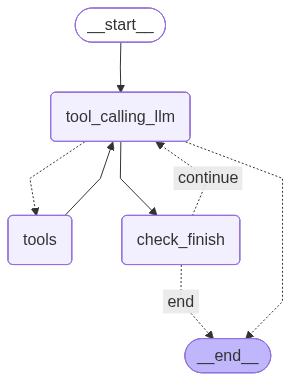

In [53]:
from IPython.display import Image, display


# Get graph visualization
display(Image(graph.get_graph().draw_mermaid_png()))

In [54]:


state = {
    "messages": [
        SystemMessage(
            content="""
You are a stock investment assistant. 
Your task is to help users analyze their stock portfolios and provide insights based on various analyses.
You have access to a range of tools that can assist you in this task, including stock-based analysis, allocation-based analysis, portfolio-based analysis, correlation-based analysis, fundamental document analysis, memory retrieval, explainability tools, Q&A capabilities, SWOT analysis, and a search tool.

You MUST call the appropriate tool when all required inputs are present.
"""
        )
    ]
}

while True:
    user_input = input("User: ").strip()
    if user_input.lower() in ["exit", "quit", "no"]:
        print("Assistant: Goodbye!")
        break
    
    print("User:", user_input)
    
    thread_id = str(uuid.uuid4())
    state = State({"messages": [HumanMessage(content=user_input)]})

    result = await graph.ainvoke(
        state,
        config={"configurable": {"thread_id": thread_id}},
    )

    
    interrupts = result.get("__interrupt__", [])
    if not interrupts:
        break

    prompt_to_human = interrupts[0].value
    print(f"HITL: {prompt_to_human}")
    decision = input("Your decision: ").strip()
    print(f"Your decision: {decision}")

    result = await graph.ainvoke(
        Command(resume=decision),
        config={"configurable": {"thread_id": thread_id}},
    )

    messages = result.get("messages", [])
    if messages:
        # Print the latest non-empty message content to avoid blank bot output.
        bot_text = ""
        for msg in reversed(messages):
            content = getattr(msg, "content", "")
            if str(content).strip():
                bot_text = str(content)
                break
        if bot_text:
            print(f"Bot: {bot_text}\n")

User: Hi


CancelledError: 